# Kármán vortex street with the common MORFE API

Two-dimensional incompressible flow past a cylinder loses stability at $Re_c \approx 49$ through a Hopf bifurcation: the Kármán vortex street. This example reduces the 57 860-DOF Navier–Stokes model to a **single complex ODE**, the Stuart–Landau equation

$$\dot z_1 = \lambda z_1 + c_{101}\,z_1\eta' + c_{210}\,z_1|z_1|^2 + \dots$$

The Reynolds number rides along as a parametric coordinate $\eta' = 1/Re - 1/Re_0$, so one run at the expansion point describes the whole bifurcation neighbourhood. Steps 1 to 4 build the reduction; steps 5 to 7 read the limit-cycle branch, the shedding frequency and the peak lift straight off it. The committed output uses order 3. To reproduce the order-9 reference, change `order = 3` to `order = 9` and rerun the notebook.

Before the first run, initialise the example environment from the MORFEFerrite repository root with `julia --project=examples/12_karman_hopf -e 'using Pkg; Pkg.develop(path="."); Pkg.instantiate()'`. This selects MORFEFerrite from the current checkout and downloads MORFE from Julia's package registry.

The first cell activates and instantiates that environment. `NSE` is only a short name for the fluid backend used to describe the flow case; `build_model`, `parametrise` and `normal_form_branch` belong to the common API.

In [1]:
import Pkg
Pkg.activate(@__DIR__; io = devnull)
Pkg.instantiate(; io = devnull)
using MORFE, MORFEFerrite
const NSE = MORFEFerrite.FluidNavierStokes # for incompressible Navier-Stokes

┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Pkg/src/API.jl:1322


MORFEFerrite.FluidNavierStokes

## 1. Describe the fluid case

Choose the polynomial expansion order directly: `3` is the quick demonstration and `9` is the reference calculation.

`fluid_model` reads the mesh and assembles everything the flow problem needs: the P2/P1 Taylor-Hood spaces and their boundary conditions, the Newton solve for the steady base flow, the operators of the system linearised about it, and the viscous pieces that carry the Reynolds dependence. `Re = 49.03` is the expansion point, just above the critical Reynolds number. The mesh is a Turek–Schäfer channel with a ⌀0.1 m cylinder; its diameter is the reference length in $\nu = D/Re$.

In [2]:
order = 3  # Change to 9 for the reference calculation.
case = NSE.fluid_model(joinpath(@__DIR__, "cylinder_flow.msh"); Re = 49.03)

[ Info: Grid: 12943 cells, 6636 nodes
[ Info: DOFs: 59066 total


Info    : Reading '/Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/12_karman_hopf/cylinder_flow.msh'...
Info    : 18 entities
Info    : 6636 nodes
Info    : 13272 elements
Info    : Done reading '/Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/12_karman_hopf/cylinder_flow.msh'


[ Info:   Velocity per cell : 12  (range 1:12)
[ Info:   Pressure per cell : 3 (range 13:15)
[ Info:   Free DOFs (steady state) : 57860
[ Info:   Free DOFs (DPIM)         : 57860  (inlet frozen)


[ Info: FEM: 57860 free DOFs (steady state), 57860 (DPIM)
[ Info:   Newton iter 1 (Re₀ = 49.03): ‖R‖ = 0.1002


[ Info:   Newton iter 2 (Re₀ = 49.03): ‖R‖ = 0.03774
[ Info:   Newton iter 3 (Re₀ = 49.03): ‖R‖ = 0.005448


[ Info:   Newton iter 4 (Re₀ = 49.03): ‖R‖ = 0.001838
[ Info:   Newton iter 5 (Re₀ = 49.03): ‖R‖ = 0.0001751


[ Info:   Newton iter 6 (Re₀ = 49.03): ‖R‖ = 7.552e-7
[ Info:   Newton iter 7 (Re₀ = 49.03): ‖R‖ = 5.865e-11


[ Info: Linear operators assembled (Re₀ = 49.03)
[ Info:   B₁ nnz = 1691298,  B₀ nnz = 1691298
[ Info:   B₁ rank check: 51224 of 57860 diagonal entries nonzero
[ Info: K_visc assembled: 1691298 nonzeros in free subspace


AssembledFluidModel (Ferrite P2/P1 Taylor-Hood)
  Re₀       : 49.03
  free DOFs : 57860 (steady state), 57860 (DPIM)
  operators : B₀ nnz=1691298  B₁ nnz=1691298  K_visc nnz=1160300
  base flow : ‖s₀‖∞ = 2.305993117642014

## 2. Select the Hopf pair

Which modes span the manifold is a modelling decision, so it is made here in the driver: the backend has no policy about it. The two master coordinates are the Hopf pair; every other computed mode is an off-manifold target used only for diagnostics.

The eigenproblem $-B_0\,y = \lambda B_1 y$ is solved by shift-invert ARPACK. Because the shift $\sigma$ is complex, ARPACK returns only the modes near $\sigma$, and a strongly oscillatory mode's conjugate sits near $\bar\sigma$ and is never computed. `solve_hopf_eigenproblem` appends those missing halves itself, which is exact for real $B_0$ and $B_1$, so `conjugate_index` names the true partner of `hopf_index`. `case.B` is the pair $(B_0, B_1)$, the assembled model's linear operators in the order MORFE's model wants them. The descriptor system is $B_1\dot x + B_0 x = F$, so its eigenproblem carries a sign that belongs to the equation rather than to the caller; passing the tuple whole keeps it there.

In [3]:
spectrum = NSE.solve_hopf_eigenproblem(case.B;
    nev = 40, sigma_re = 3.0, sigma_im = 8.0)

master = [spectrum.hopf_index, spectrum.conjugate_index]
outer = setdiff(eachindex(spectrum.eigenvalues), master)
spectrum.eigenvalues[master] # print the Hopf pair

  Shift σ = 3.0 + 8.0im,  nev = 40,  ncv = 120,  n = 57860



    #   Re(λ)           Im(λ)           |λ|         


  ────────────────────────────────────────────────────
    1      +0.004029    +16.859170     16.859170
    2      -2.113876     -0.000000      2.113876


    3      -2.911776     +0.011415      2.911799
    4      -2.911776     -0.011415      2.911799
    5      -5.135423     +0.000000      5.135423
    6      -6.690747     +0.000005      6.690747
    7     -10.251990     +4.471935     11.184878
    8     -11.022533     +7.464033     13.311950
    9      -6.542148    +18.415390     19.542935
   10     -11.176325    +10.696573     15.470195
   11      -9.412933     +0.572271      9.430313
   12      -9.413069     -0.572398      9.430456
   13     -11.565875     +2.109541     11.756684
   14     -11.894098    +13.952487     18.334161
   15     -13.207551     +4.100003     13.829296
   16     -13.691153     +8.310084     16.015778
   17     -11.720046     -0.000408     11.720046
   18     -13.867732     +5.986819     15.104834
   19     -13.789959    +10.611149     17.399984
   20     -13.493065     +1.729825     13.603496
   21     -11.565939     -2.107543     11.756389
   22     -14.160896    +12.755380     19.058612
   23     -13.204521

2-element Vector{ComplexF64}:
 0.00402856110873584 + 16.85916985616479im
 0.00402856110873584 - 16.85916985616479im

## 3. Build the MORFE model

`build_model` converts the fluid case and its spectrum into MORFE's physics-independent model and spectral data. It computes the left eigenvectors of the master modes only, each costing its own adjoint factorisation, and conjugates the partner of a pair rather than solving for it, so the conjugate symmetry the reduction relies on holds by construction.

`scale = 1e-2` is a mode gauge: a uniform factor on both eigenvector sides, for conditioning. It changes what `W` and `R` mean, so coefficients from two gauges are not comparable, which is why it is written at the call site rather than hidden inside a default. The returned `meta` contains auxiliary backend information, including the conjugate permutation displayed below.

In [4]:
(; model, spectral, meta) = build_model(case, spectrum;
    master = master, outer = outer, expansion_order = order, scale = 1e-2)
meta.conjugate_permutation # print the conjugate permutation

3-element Vector{Int64}:
 2
 1
 3

## 4. Parametrise the invariant manifold

`parametrise` computes the polynomial manifold map `W` and its reduced dynamics `R` up to the chosen order. The resonance configuration keeps near-resonant monomials in complex normal form; `tol_relative = 0.1` judges each target on its own frequency scale, flagging a monomial whose detuning is under 10 % of that target's $|\lambda|$. `outer_targets = true` also measures the monomials against the off-manifold modes, a diagnostic only, since the solve reads the master block alone.

Evaluating `R` at the end of the cell displays the reduced system: row 1 is the Stuart–Landau equation, row 2 its conjugate, and row 3 is $\dot\eta' = 0$, the frozen Reynolds coordinate. The Hopf bifurcation is supercritical when $\mathrm{Re}\,c_{210} < 0$.

In [5]:
W, R = parametrise(model, spectral, order;
    resonance = ResonanceConfig(style = :complex_normal_form, tol_relative = 0.1,
        outer_targets = true))
R # print reduced dynamics

┌ Info: conjugate_permutation is active — the following assumptions must hold:
│   1. Real-valued FOM: all matrices in model.linear_terms and all nonlinear/force terms must have real-valued entries (eltype <: Real or purely-real complex).
│   2. Each mode either comes in a complex conjugate pair with another mode, or is self-paired  meaning it has a real eigenvalue and a real-valued mode shape.
│   3. Eigenvalue conjugacy is necessary but NOT sufficient for paired modes; the right eigenvectors must satisfy master_right_modes[:, perm[r]] = conj(master_right_modes[:, r]).
│   4. If external modes are present (N_EXT > 0): the same pairing rules apply to the external eigenvalues, encoded in the NVAR-length permutation.
└ Passing an incorrect permutation silently corrupts the parametrisation and reduced-dynamics.
┌ Info: Using optimised FEM path: cached per-element loop
└   n_fem_terms = 1


ReducedDynamics{2, 3, ComplexF64}(DensePolynomial{ComplexF64, 3, 2, Matrix{ComplexF64}}(ComplexF64[0.00402856110873584 + 16.85916985616479im 0.0 + 0.0im … 0.0 - 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.00402856110873584 - 16.85916985616479im … 2981.130007368557 - 95.30710608426244im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im], MultiindexSet{3}(StaticArraysCore.SVector{3, Int64}[[1, 0, 0], [0, 1, 0], [0, 0, 1], [2, 0, 0], [1, 1, 0], [1, 0, 1], [0, 2, 0], [0, 1, 1], [0, 0, 2], [3, 0, 0], [2, 1, 0], [2, 0, 1], [1, 2, 0], [1, 1, 1], [1, 0, 2], [0, 3, 0], [0, 2, 1], [0, 1, 2], [0, 0, 3]], [0, 0, 3, 9, 19]), [3, 3, 3]), 1)

## 5. Read the bifurcation diagram off `R`

`R` already contains the answer. With a single conjugate pair in complex normal form every surviving monomial has $a - b = 1$, so substituting $z_1 = \rho e^{i\theta}$ gives every term the same factor $e^{i\theta}$ and $R_1$ loses its phase dependence. Matching $\dot z_1 = (\dot\rho + i\rho\dot\theta)e^{i\theta}$ against it separates amplitude from phase:

$$\dot\rho = \mathrm{Re}\,R_1(\rho, \rho, \eta') \qquad\qquad \Omega = \frac{\mathrm{Im}\,R_1(\rho, \rho, \eta')}{\rho}$$

A limit cycle is a nonzero root of $\mathrm{Re}\,R_1(\rho, \rho, \eta') = 0$, and $\Omega$ read there is its frequency. Each one is a whole periodic orbit, the circle $z_1 = \rho e^{i\Omega t}$, so the branch is really a paraboloid of cycles growing out of the base flow at $\mathrm{Re}_c$; the amplitude plots further down are that surface seen edge on.

`normal_form_branch` does all of it and returns plain vectors. At fixed $\rho$ the equation is a *polynomial* in $\eta'$, so the branch is solved for the parameter rather than continued in it: one companion-matrix root-solve per amplitude, with no step size, no initial guess and no fold to chase, since a fold in $\rho$ against Re is just a monotone $\eta'(\rho)$.

Two keywords carry the modelling decisions. `parameter_range` keeps the sweep physical, because the $\eta'$-polynomial also has roots far outside the expansion neighbourhood: at order 3 a second one at $\eta' \approx 0.071$, which is Re $\approx 11$. And `sheet = :primary` follows the branch out of the Hopf point rather than returning every root, which from order 9 includes a second sheet at large amplitude.

In [6]:
Re₀ = 49.03
to_Re(η) = 1 / (η + 1 / Re₀)
to_η(Re) = 1 / Re - 1 / Re₀

sweep = (parameter = 1, sheet = :primary, amplitudes = range(0, 4; length = 500),
    parameter_range = (to_η(70.0), to_η(48.0)))

branch = normal_form_branch(R; sweep...)
Re_c = to_Re(branch.parameter[1]) # the ρ = 0 end of the branch is the Hopf point

48.98435080480238

## 6. A physical observable: the lift

$\rho$ is measured in the normal-form coordinate, whose scale is the mode gauge set in step 3,
so it is not a quantity anyone measures. Physical observables are projections of `W`, and once
the manifold is known they cost no full-order work: project the functional through `W` once,
then evaluate a small polynomial.

`lift_functional` returns the pressure-traction weight vector on the cylinder, and
`lift_polynomial` pushes it through `W` to give $L(z_1, \bar z_1, \eta')$, one complex
coefficient per monomial. On the limit cycle the orbit is the circle $z_1 = \rho e^{i\theta}$,
so the peak lift is a maximum over one phase sweep. Subtracting the value at $\rho = 0$ leaves
the *fluctuating* lift, without the base flow's own contribution.

In [7]:
l_free, L0 = NSE.lift_functional(case)
L_coeffs, mset_L = NSE.lift_polynomial(W, l_free)
L = DensePolynomial(L_coeffs, mset_L)

θ = range(0, 2π; length = 257)[1:256]

function max_lift(P, ρ, η)
    base = evaluate(P, [0.0im, 0.0im, complex(η)])
    maximum(abs(real(evaluate(P, [ρ * cis(t), ρ * cis(-t), complex(η)]) - base)) for t in θ)
end

max_lift(L, branch.amplitude[end], branch.parameter[end]) # peak lift at the far end

0.018935207813823792

## 7. Convergence with expansion order

The cohomological solve is **graded**: a degree-$N$ coefficient never depends on degrees above
$N$. Truncating the order-9 coefficients therefore gives the order-$N$ ROM exactly, and the
order study costs nothing beyond this one run. `restrict_ReducedDynamics_to_degree` truncates
`R`; the lift is truncated the same way, on the projected polynomial rather than on `W`, which
at order 9 is a ~193 MB array.

Where the curves lie on top of one another the truncation has converged. Where they separate,
the reduced state has left the region where the expansion converges, and a branch that folds
back does so as a truncation artifact rather than as physics.

MORFE draws nothing itself. `normal_form_branch` returns vectors, and the plotting below is an
explicit Makie call on them.

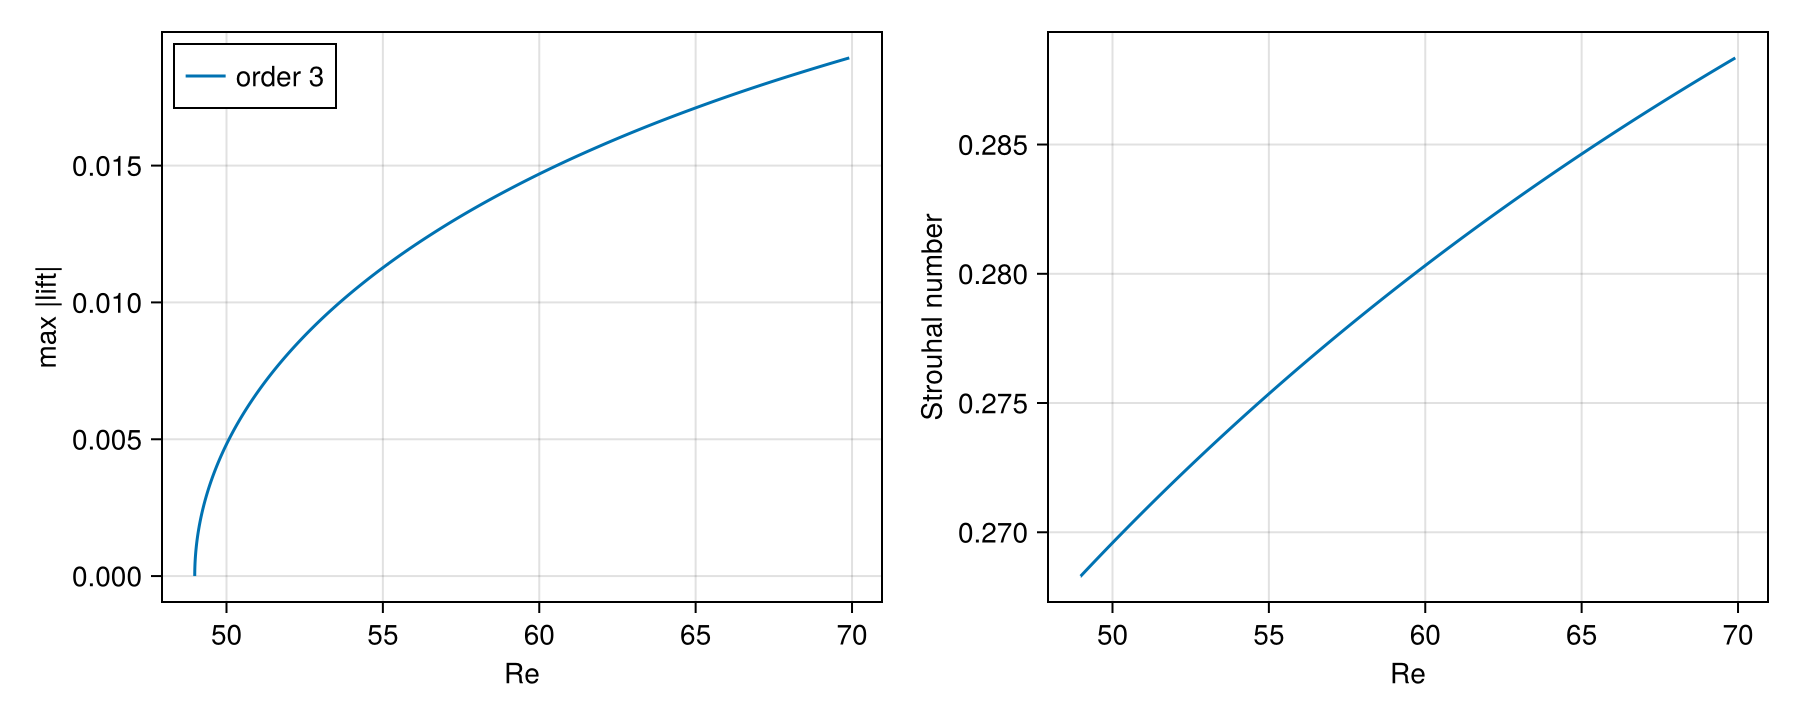

In [8]:
using CairoMakie

D = case.fom.reference_length      # 0.1 m, the reference length in ν = D/Re
strouhal(Ω) = Ω * D / (2π * NSE.U_MEAN)

curves = map(3:2:order) do N
    b = normal_form_branch(restrict_ReducedDynamics_to_degree(R, N); sweep...)
    P = MORFE.Polynomials.restrict_polynomial_to_degree(L, N)
    (; N, b.amplitude, b.frequency, eta = b.parameter, Re = to_Re.(b.parameter),
        St = strouhal.(b.frequency), lift = max_lift.(Ref(P), b.amplitude, b.parameter))
end

fig = Figure(size = (900, 360))
ax_lift = Axis(fig[1, 1]; xlabel = "Re", ylabel = "max |lift|")
ax_st = Axis(fig[1, 2]; xlabel = "Re", ylabel = "Strouhal number")
for c in curves
    lines!(ax_lift, c.Re, c.lift; label = "order $(c.N)")
    lines!(ax_st, c.Re, c.St; label = "order $(c.N)")
end
axislegend(ax_lift; position = :lt)
fig

## Optional: save the ROM and the branch

The common saver writes `W`, `R`, their coefficient table and a summary to the example's
`results` directory; `validate.jl` reads the coefficient table it writes. `branch.csv` holds
every curve drawn above, and the order-9 file is what the
[Kármán tutorial page](https://morfeproject.github.io/MORFE.jl/tutorials/karman.html) plots.

The rows stay in amplitude order. Orders 5 and 9 fold, and a curve sorted by Re instead would
zig-zag across its own fold.

In [9]:
MORFE.save_rom(joinpath(@__DIR__, "results"), W, R;
    external_system = meta.external_system)

open(joinpath(@__DIR__, "results", "data", "branch.csv"), "w") do io
    println(io, "order,eta,Re,rho,omega,St,max_abs_lift")
    for c in curves, i in eachindex(c.Re)
        println(io, join((c.N, c.eta[i], c.Re[i], c.amplitude[i], c.frequency[i],
            c.St[i], c.lift[i]), ","))
    end
end